In [ ]:
from general_utils import find_ephys_sessions
from ephys_dimension_reduction_tdr import plot_tdr_trace_by_quantile


sessions=find_ephys_sessions()

In [ ]:
import numpy as np
from ephys_dimension_reduction_tdr import tdr_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv

failed_sessions = []

for session in sessions[2]:
    try:
        binsize = '0.1'
        time_windows=[[0.3,2],[-1,0]]
  #      latent_vars=['QLearning_L2F1_softmax-choice','QLearning_L2F1_softmax-reward','QLearning_L2F1_softmax-RPE','QLearning_L2F1_softmax-deltaQ','QLearning_L2F1_softmax-sumQ',
  #      'QLearning_L2F1_softmax-chosenQ','QLearning_L2F1_softmax-chosenQ-1','QLearning_L2F1_softmax-unchosenQ-1','QLearning_L2F1_softmax-unchosenQ']
        latent_vars=['QLearning_L2F1_softmax-sumQ','QLearning_L2F1_softmax-sumQ-1']
  

        for time_window in time_windows:
            for latent_var in latent_vars:
                #time_window=[0.3,2]
                align = "go_cue"
                #latent_var = 'ForagingCompareThreshold-deltaQ-1'
                #latent_var = 'QLearning_L2F1_softmax-deltaQ-1'
                #latent_var = 'QLearning_L2F1_softmax-RPE'
                #latent_var = 'QLearning_L2F1_softmax-choice'
                psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
                df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")
                #latent_var = 'QLearning_L2F1_softmax-sumQ-1'
                keep_ids = np.asarray(df['response_trials'][0], dtype=int)
                latent_full = np.asarray(df[latent_var][0], dtype=float)

                out = tdr_from_psth(
                    psth_da,
                    latent=latent_full,
                    align=align,
                    time_window=time_window,
                    include_trials=keep_ids,
                    require_all_ids=True,
                    save_path=f"/root/capsule/scratch/tdr_{session}_{latent_var}_timewindow_{time_window[0]}_{time_window[1]}.zarr",
                    save_format="zarr",
                )

    except Exception as e:
        print(f"❌ Error in session {session}: {e}")
        failed_sessions.append(session)

print("\nAll sessions done.")
if failed_sessions:
    print("Failed sessions:")
    for s in failed_sessions:
        print(f" - {s}")
else:
    print("No errors 🎉")


In [ ]:
import xarray as xr

# Point to the directory you passed to save_path (e.g., "tdr_results.zarr")
path = "/root/capsule/scratch/tdr_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_ForagingCompareThreshold-value-1.zarr"

# Open lazily (doesn't load data into RAM yet)
ds = xr.open_zarr(path, consolidated=False)  # set True if you consolidated metadata

print(ds)  # see variables, coords, attrs



# Bring specific arrays into memory (NumPy)
Y = ds["projection_trace"].values          # (T_used, Tt)
y_fit = ds["projection"].values            # (T_used,)
w = ds["axis_w"].values                    # (N_units,)
t = ds["time"].values                      # (Tt,)
trial_ids = ds["trial_id"].values          # (T_used,)
unit_ids  = ds["unit_id"].values

# Access metadata
align = ds.attrs.get("align")
time_window_fit = tuple(ds.attrs.get("time_window_fit", ()))
cv_corr = ds.attrs.get("cv_corr")


In [20]:
import os
import xarray as xr
import numpy as np
import re
import pandas as pd
from general_utils import smart_read_csv  # assuming this is defined elsewhere

# --- Directory containing zarr results ---
to_mask=False
base_dir = "/root/capsule/scratch/"
#end_with = "QLearning_L2F1_softmax-reward_timewindow_0.3_2.zarr"
end_with="ForagingCompareThreshold-value-1_timewindow_-1_0.zarr"
#end_with="ForagingCompareThreshold-RPE_timewindow_0.3_2.zarr"
#end_with="QLearning_L2F1_softmax-RPE_timewindow_0.3_2.zarr"
#end_with="QLearning_L2F1_softmax-deltaQ-1_timewindow_-1_0.zarr"
# --- Collect matching files ---
zarr_paths = [
    os.path.join(base_dir, f)
    for f in os.listdir(base_dir)
    if f.endswith(end_with)
]

print(f"Found {len(zarr_paths)} matching files")

# --- Containers ---
Y_list, yfit_list, latent_list, latent_list_z = [], [], [], []

# --- Process each Zarr ---
for path in zarr_paths:
    # Extract session name from path
    pattern = r"(ecephys_\d{6}_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_sorted_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})"
    match = re.search(pattern, path)
    if not match:
        print(f"⚠️ Could not extract session name from {path}")
        continue
    session = match.group(1)

    # Read behavior summary
    df = smart_read_csv(f"{base_dir}/behavior_summary-{session}.csv")
    switch_trial_trials_ID = np.asarray(df["switch_trial_noreward_trials"][0], dtype=int)

    # Load dataset
    ds = xr.open_zarr(path, consolidated=False)
    trial_ids = ds["trial_id"].values

    if to_mask:
        # Boolean mask for switch trials
        mask = np.isin(trial_ids, switch_trial_trials_ID)

        # Extract only matching trials
        Y_list.append(ds["projection_trace"].values[mask])  # (T_switch × Tt)
        yfit_list.append(ds["projection"].values[mask])     # (T_switch,)
        latent_list.append(ds["latent"].values[mask])       # (T_switch,)
        latent_list_z.append(ds["latent_z"].values[mask])   # (T_switch,)

        print(f"Loaded {session}: {mask.sum()} switch trials extracted")
    else:
        
        # Extract only matching trials
        Y_list.append(ds["projection_trace"].values)  # (T_switch × Tt)
        yfit_list.append(ds["projection"].values)     # (T_switch,)
        latent_list.append(ds["latent"].values)       # (T_switch,)
        latent_list_z.append(ds["latent_z"].values)   # (T_switch,)

        print(f"Loaded {session}")

# --- Concatenate across sessions ---
Y = np.concatenate(Y_list, axis=0)
y_fit = np.concatenate(yfit_list, axis=0)
latent_inc = np.concatenate(latent_list, axis=0)
latent_inc_z = np.concatenate(latent_list_z, axis=0)

print(f"Combined Y shape: {Y.shape}")
print(f"Combined y_fit length: {y_fit.shape}")
print(f"Combined latent length: {latent_inc.shape}")


Found 30 matching files
Loaded ecephys_764787_2024-12-13_18-27-42_sorted_2024-12-17_18-31-24
Loaded ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23
Loaded ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16
Loaded ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53
Loaded ecephys_753126_2024-10-15_12-20-35_sorted_2024-11-09_19-47-57
Loaded ecephys_764791_2025-01-16_12-50-17_sorted_2025-04-25_14-11-37
Loaded ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58
Loaded ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25
Loaded ecephys_753125_2024-10-15_16-16-22_sorted_2024-11-09_19-57-50
Loaded ecephys_753125_2024-10-14_15-37-15_sorted_2024-11-09_20-07-38
Loaded ecephys_781471_2025-03-31_14-33-03_sorted_2025-04-01_15-50-16
Loaded ecephys_764787_2024-12-12_11-54-14_sorted_2024-12-13_10-39-18
Loaded ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23
Loaded ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48
Loaded ece

/tmp/ipykernel_266386/3197573768.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap(cmap, len(kept_bins))


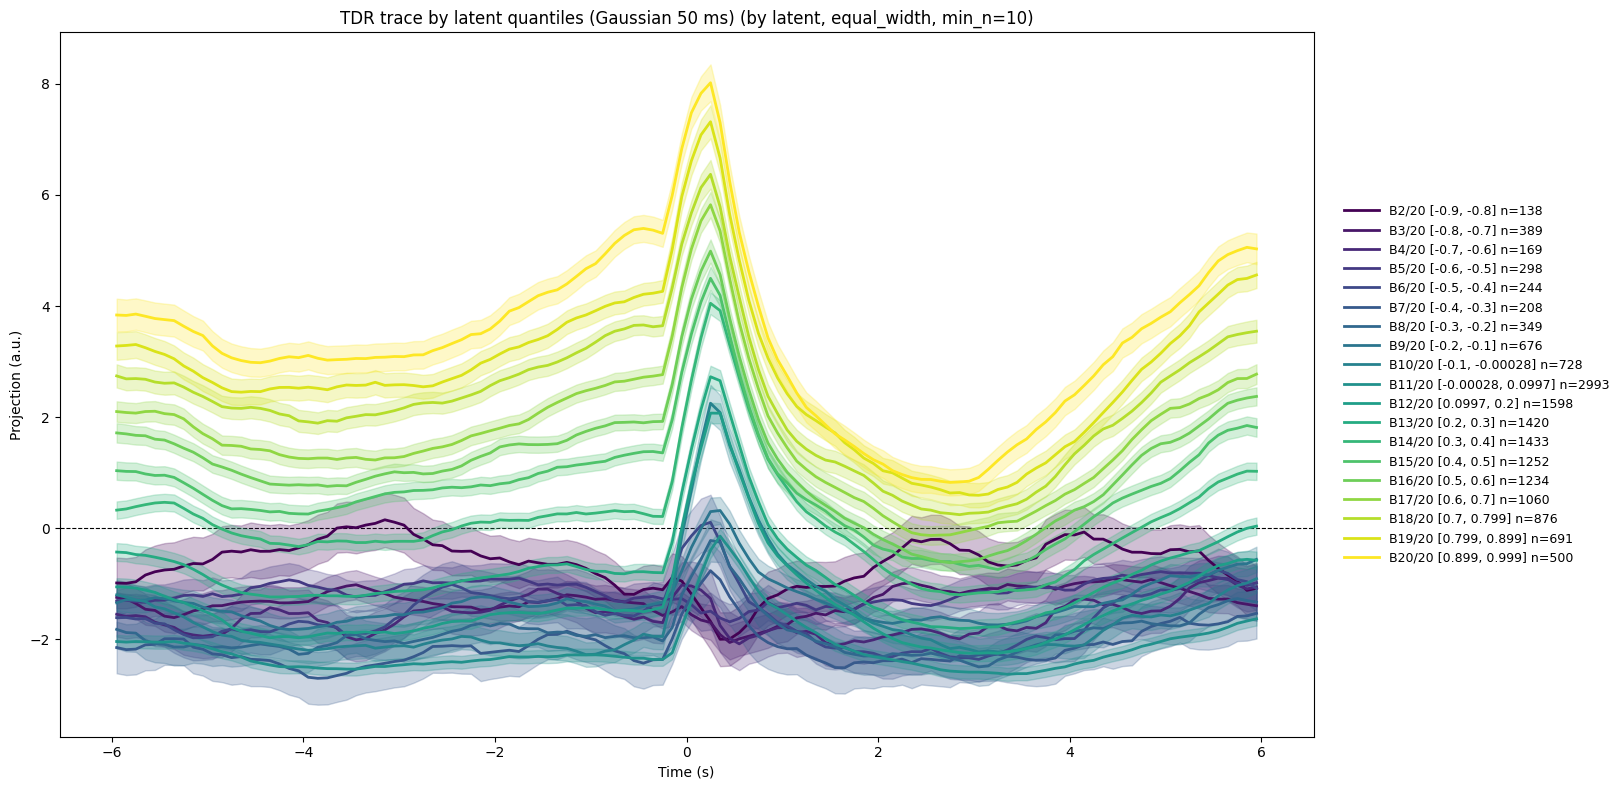

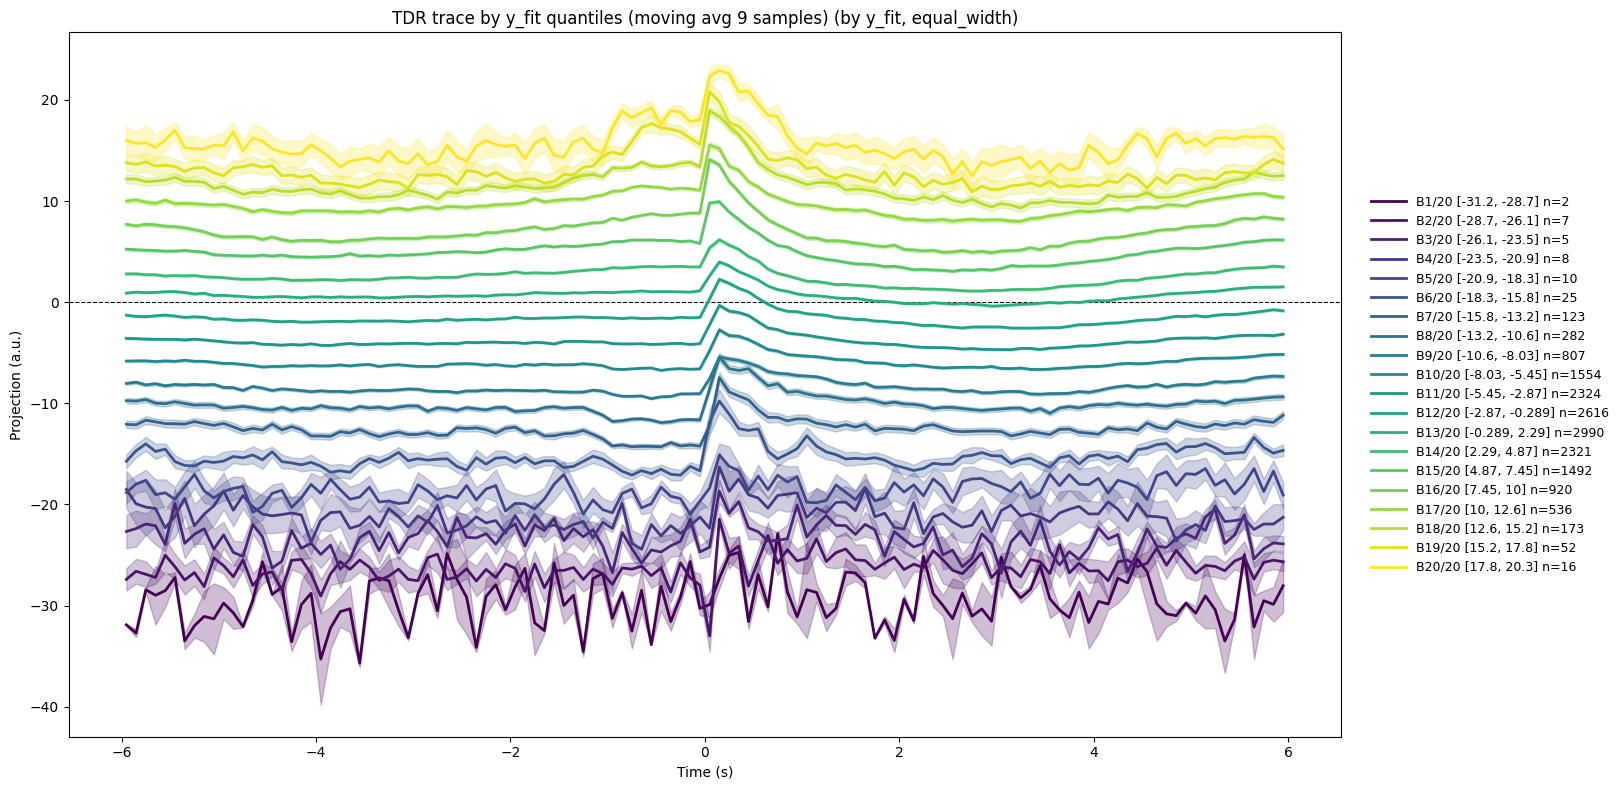

In [21]:
# Get outputs
#Y = ds["projection_trace"]           # (n_trials, n_timepoints)
#y_fit = ds["projection"].values             # (n_trials,)
#latent_inc = ds["latent"].values 
t = ds["time"].values           # (n_timepoints,)


# 1) Gaussian smoothing with sigma = 50 ms before averaging
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=20,
    group_by="latent", ci="sem", show_trials=False,
    min_traces_per_bin=10,
    smooth={"method":"moving", "window":5, "unit":"samples"},
    title="TDR trace by latent quantiles (Gaussian 50 ms)"
)

# 2) Moving-average smoothing with a 9-sample window
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc_z, n_quantiles=20,
    y_fit=y_fit, group_by="y_fit", ci="sem",
    smooth={"method":"moving", "window":1, "unit":"samples"},
    title="TDR trace by y_fit quantiles (moving avg 9 samples)"
)


In [ ]:
Y_list

In [ ]:
# run individual sessions
import os
import xarray as xr
import numpy as np
import re
import pandas as pd
from general_utils import smart_read_csv  # assuming this is defined elsewhere

# --- Directory containing zarr results ---
base_dir = "/root/capsule/scratch/"
end_with = "QLearning_L2F1_softmax-deltaQ_timewindow_-1_0.zarr"
end_with="ForagingCompareThreshold-value-1_timewindow_-1_0.zarr"
# --- Collect matching files ---
zarr_paths = [
    os.path.join(base_dir, f)
    for f in os.listdir(base_dir)
    if f.endswith(end_with)
]

print(f"Found {len(zarr_paths)} matching files")


# --- Process each Zarr ---
for path in zarr_paths:
    try: 
        Y_list, yfit_list, latent_list, latent_list_z = [], [], [], []
        # Extract session name from path
        pattern = r"(ecephys_\d{6}_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_sorted_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})"
        match = re.search(pattern, path)
        if not match:
            print(f"⚠️ Could not extract session name from {path}")
            continue
        session = match.group(1)

        # Read behavior summary
        df = smart_read_csv(f"{base_dir}/behavior_summary-{session}.csv")
        switch_trial_trials_ID = np.asarray(df["switch_trial_reward_trials"][0], dtype=int)

        # Load dataset
        ds = xr.open_zarr(path, consolidated=False)
        trial_ids = ds["trial_id"].values

        # Boolean mask for switch trials
        mask = np.isin(trial_ids, switch_trial_trials_ID)

        # Extract only matching trials
        Y_list.append(ds["projection_trace"].values[mask])  # (T_switch × Tt)
        yfit_list.append(ds["projection"].values[mask])     # (T_switch,)
        latent_list.append(ds["latent"].values[mask])       # (T_switch,)
        latent_list_z.append(ds["latent_z"].values[mask])   # (T_switch,)


        Y = np.concatenate(Y_list, axis=0)
        y_fit = np.concatenate(yfit_list, axis=0)
        latent_inc = np.concatenate(latent_list, axis=0)
        latent_inc_z = np.concatenate(latent_list_z, axis=0)
        t = ds["time"].values           # (n_timepoints,)


        # 1) Gaussian smoothing with sigma = 50 ms before averaging
        plot_tdr_trace_by_quantile(
            Y, t, latent=latent_inc, n_quantiles=10,
            group_by="latent", ci="sem", show_trials=False,
            min_traces_per_bin=1,
            smooth={"method":"moving", "window":5, "unit":"samples"},
            title="TDR trace by latent quantiles (Gaussian 50 ms)"
        )

        # 2) Moving-average smoothing with a 9-sample window
        plot_tdr_trace_by_quantile(
            Y, t, latent=latent_inc_z, n_quantiles=20,
            y_fit=y_fit, group_by="y_fit", ci="sem",
            smooth={"method":"moving", "window":1, "unit":"samples"},
            title="TDR trace by y_fit quantiles (moving avg 9 samples)"
        )
        print(f"Loaded {session}: {mask.sum()} switch trials extracted")
    except:
        pass



Found 30 matching files
Loaded ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33 with 553 trials
Loaded ecephys_764790_2024-12-20_16-56-37_sorted_2024-12-22_00-06-37 with 536 trials
Loaded ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23 with 313 trials
Loaded ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20 with 580 trials
Loaded ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48 with 440 trials
Loaded ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23 with 370 trials
Loaded ecephys_764791_2025-01-15_13-08-58_sorted_2025-01-16_11-46-50 with 390 trials
Loaded ecephys_764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57 with 497 trials
Loaded ecephys_753126_2024-10-11_13-14-24_sorted_2024-11-09_19-18-21 with 575 trials
Loaded ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57 with 470 trials
Loaded ecephys_764790_2024-12-17_16-57-52_sorted_2024-12-20_18-46-41 with 613 trials
Loaded ecephys_776293_2025-02-14_15-19-17

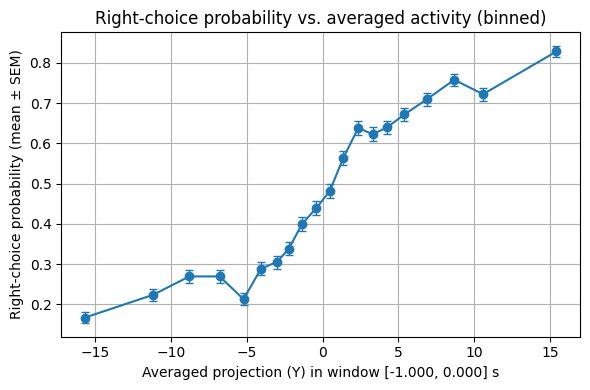

In [16]:
# -*- coding: utf-8 -*-
"""
Aggregate all trials across matching Zarr files, attach choices, average Y over a time window,
bin by averaged activity, and plot right-choice probability (mean ± SD or SEM) per bin.

Assumptions per Zarr:
- Variables:
    projection_trace (trial, time)          # Y
    projection        (trial,)              # y_fit
    latent            (trial,)              # latent_inc
    latent_z          (trial,)              # latent_inc_z
    trial_id          (trial,)              # integer IDs that match behavior CSV
    time_for_projection (time,) or time (time,)   # seconds relative to align event

Behavior CSV path for each session:
    {base_dir}/behavior_summary-{<session>}.csv
with keys:
    'left_choice_trials'  -> list[int]
    'right_choice_trials' -> list[int]
(Trials not in either list are considered unknown/no-response and dropped.)

Plotting rules:
- Matplotlib only, one chart, no explicit color styling set.
"""

import os
import re
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Literal
from general_utils import smart_read_csv  # assumed available in your environment

# -------------------- User configuration --------------------
base_dir = "/root/capsule/scratch/"

# Choose the Zarr suffix you want to analyze:
end_with = "QLearning_L2F1_softmax-deltaQ-1_timewindow_-1_0.zarr"

# Time window (in seconds) over which to average Y (e.g., pre-go-cue or post-reward)
time_window: Tuple[float, float] = (-1, 0.0)

# Binning options
binning: Literal["quantile", "uniform"] = "quantile"
n_bins: int = 20

# Error bar mode: "SD" for standard deviation, "SEM" for standard error of the mean
error_mode: Literal["SD", "SEM"] = "SEM"

# Optional: save arrays to disk
save_arrays: bool = False
save_prefix = os.path.join(base_dir, "right_prob_vs_activity")
# ------------------------------------------------------------


def collect_zarr_paths(base_dir: str, end_with: str):
    """Find Zarr files under base_dir that end with the given suffix."""
    return [
        os.path.join(base_dir, f)
        for f in os.listdir(base_dir)
        if f.endswith(end_with)
    ]


def extract_session_name(path: str) -> str:
    """Extract ecephys session name from filename."""
    pattern = (
        r"(ecephys_\d{6}_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}"
        r"_sorted_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})"
    )
    m = re.search(pattern, path)
    if not m:
        raise ValueError(f"Could not extract session name from {path}")
    return m.group(1)


def get_time_vector(ds: xr.Dataset) -> np.ndarray:
    """Return the time vector from the dataset, trying common keys."""
    if "time_for_projection" in ds:
        return ds["time_for_projection"].values
    elif "time" in ds:
        return ds["time"].values
    else:
        raise KeyError("No time axis found: expected 'time_for_projection' or 'time'.")


def build_choice_vector(trial_ids: np.ndarray, df_behavior: pd.DataFrame) -> np.ndarray:
    """
    Build per-trial choice array aligned to trial_ids.
    Returns array of shape (T,) with values:
        1 for right, 0 for left, np.nan for trials in neither list.
    """
    try:
        left_trials = np.asarray(df_behavior["left_choice_trials"][0], dtype=int)
    except KeyError:
        left_trials = np.asarray([], dtype=int)
    try:
        right_trials = np.asarray(df_behavior["right_choice_trials"][0], dtype=int)
    except KeyError:
        right_trials = np.asarray([], dtype=int)

    right_set = set(right_trials.tolist())
    left_set = set(left_trials.tolist())

    choice = np.full(trial_ids.shape[0], np.nan, dtype=float)
    for i, tid in enumerate(trial_ids):
        if tid in right_set:
            choice[i] = 1.0
        elif tid in left_set:
            choice[i] = 0.0
        # else remains NaN (e.g., no-response)
    return choice


def time_window_mask(t: np.ndarray, window: Tuple[float, float]) -> np.ndarray:
    """Return boolean mask selecting indices within [t0, t1]."""
    t0, t1 = window
    if t0 > t1:
        raise ValueError("time_window must satisfy t0 <= t1")
    return (t >= t0) & (t <= t1)


def bin_activity_and_compute_stats(
    x: np.ndarray,
    y_right01: np.ndarray,
    n_bins: int,
    method: Literal["quantile", "uniform"] = "quantile",
    error_mode: Literal["SD", "SEM"] = "SD",
):
    """
    x: activity (ΣT,)
    y_right01: 0/1 choices (ΣT,)
    Returns:
        bin_centers (ΣB,),
        right_prob_mean (ΣB,),
        right_prob_err (ΣB,),  # SD or SEM
        counts (ΣB,),
        method_used (str),
        edges (ΣB+1,)
    """
    if method == "quantile":
        qs = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(x, qs))
        if edges.size < 3:
            # Pathological case (e.g., constant x) -> fallback to uniform edges
            xmin, xmax = float(np.min(x)), float(np.max(x))
            edges = np.linspace(xmin, xmax, n_bins + 1)
            method_used = "uniform (fallback)"
        else:
            method_used = "quantile"
    else:
        xmin, xmax = float(np.min(x)), float(np.max(x))
        edges = np.linspace(xmin, xmax, n_bins + 1)
        method_used = "uniform"

    # Digitize into bins [edges[i], edges[i+1])
    inds = np.digitize(x, edges, right=False) - 1
    inds = np.clip(inds, 0, len(edges) - 2)

    means, errs, centers, counts = [], [], [], []
    for b in range(len(edges) - 1):
        mask = inds == b
        cnt = int(np.sum(mask))
        counts.append(cnt)

        if cnt > 0:
            p = float(np.mean(y_right01[mask]))
            # SD for binary data is sqrt(p*(1-p)) if treated as Bernoulli; here we compute sample SD or SEM
            if cnt > 1:
                sd = float(np.std(y_right01[mask], ddof=1))
            else:
                sd = 0.0
            err = sd if error_mode == "SD" else (sd / np.sqrt(cnt) if cnt > 0 else np.nan)
            c = float(np.mean(x[mask]))  # center as mean activity within the bin
        else:
            p = np.nan
            err = np.nan
            c = float(0.5 * (edges[b] + edges[b + 1]))

        means.append(p)
        errs.append(err)
        centers.append(c)

    return (
        np.asarray(centers),
        np.asarray(means),
        np.asarray(errs),
        np.asarray(counts),
        method_used,
        np.asarray(edges),
    )


def main():
    # --- Find Zarr files ---
    zarr_paths = collect_zarr_paths(base_dir, end_with)
    print(f"Found {len(zarr_paths)} matching files")
    if not zarr_paths:
        raise RuntimeError("No matching Zarr files found. Check base_dir/end_with.")

    # --- Accumulators across sessions ---
    Y_list, yfit_list, latent_list, latent_list_z = [], [], [], []
    choice_list, trial_id_list = [], []
    tvec_ref = None  # Will keep the last time vector seen (assume consistent across files)

    # --- Load each Zarr and corresponding behavior ---
    for path in zarr_paths:
        try:
            session = extract_session_name(path)
        except ValueError as e:
            print(f"⚠️ {e}")
            continue

        # Behavior CSV
        df = smart_read_csv(f"{base_dir}/behavior_summary-{session}.csv")

        # Dataset
        ds = xr.open_zarr(path, consolidated=False)

        # Arrays
        trial_ids = np.asarray(ds["trial_id"].values)
        Y = np.asarray(ds["projection_trace"].values)   # (T, Tt)
        y_fit = np.asarray(ds["projection"].values)     # (T,)
        latent = np.asarray(ds["latent"].values)        # (T,)
        latent_z = np.asarray(ds["latent_z"].values)    # (T,)
        tvec = np.asarray(get_time_vector(ds))          # (Tt,)

        # Basic consistency checks
        T = trial_ids.shape[0]
        if not (Y.shape[0] == T == y_fit.shape[0] == latent.shape[0] == latent_z.shape[0]):
            raise ValueError(f"Shape mismatch in {session}: "
                             f"Y={Y.shape}, y_fit={y_fit.shape}, latent={latent.shape}, latent_z={latent_z.shape}, T={T}")

        # Build per-trial choices aligned to Y
        choice = build_choice_vector(trial_ids, df)

        # Append
        Y_list.append(Y)
        yfit_list.append(y_fit)
        latent_list.append(latent)
        latent_list_z.append(latent_z)
        choice_list.append(choice)
        trial_id_list.append(trial_ids)
        tvec_ref = tvec  # keep last seen (assume same across sessions)

        print(f"Loaded {session} with {T} trials")

    # --- Concatenate across sessions ---
    Y_all = np.concatenate(Y_list, axis=0)           # (ΣT, Tt)
    y_fit_all = np.concatenate(yfit_list, axis=0)    # (ΣT,)
    latent_all = np.concatenate(latent_list, axis=0) # (ΣT,)
    latent_z_all = np.concatenate(latent_list_z, axis=0)
    choice_all = np.concatenate(choice_list, axis=0) # (ΣT,)
    trial_ids_all = np.concatenate(trial_id_list, axis=0)

    print(f"Combined Y shape: {Y_all.shape}")
    print(f"Combined y_fit length: {y_fit_all.shape}")
    print(f"Combined latent length: {latent_all.shape}")
    print(f"Combined choices length: {choice_all.shape}")

    # --- Average Y over the requested time window ---
    tmask = time_window_mask(tvec_ref, time_window)
    if not np.any(tmask):
        raise ValueError(f"No time samples fall in window {time_window}. Check units/range.")
    Y_avg = np.nanmean(Y_all[:, tmask], axis=1)  # (ΣT,)

    # --- Keep only trials with known choices (exclude NaN = no-response/unknown) ---
    valid = ~np.isnan(choice_all)
    Y_avg_valid = Y_avg[valid]
    choice_valid = choice_all[valid].astype(float)

    # --- Bin activity and compute mean ± error per bin ---
    bin_centers, right_prob, right_err, counts, method_used, edges = bin_activity_and_compute_stats(
        x=Y_avg_valid,
        y_right01=choice_valid,
        n_bins=n_bins,
        method=binning,
        error_mode=error_mode,
    )

    print(f"Binning method used: {method_used}")
    print("Per-bin counts:", counts.tolist())

    # --- Plot: right-choice probability vs activity bins with error bars ---
    fig = plt.figure(figsize=(6, 4))
    plt.errorbar(
        bin_centers,
        right_prob,
        yerr=right_err,
        fmt="-o",
        elinewidth=1,
        capsize=3,
    )
    plt.xlabel(f"Averaged projection (Y) in window [{time_window[0]:.3f}, {time_window[1]:.3f}] s")
    ylabel = "Right-choice probability (mean ± SD)" if error_mode == "SD" else "Right-choice probability (mean ± SEM)"
    plt.ylabel(ylabel)
    plt.title("Right-choice probability vs. averaged activity (binned)")
    plt.grid(True, which="both", axis="both")
    plt.tight_layout()
    plt.show()

    # --- Optional: save arrays for downstream analyses ---
    if save_arrays:
        np.save(f"{save_prefix}_Y_avg_valid.npy", Y_avg_valid)
        np.save(f"{save_prefix}_choice_valid.npy", choice_valid)
        np.save(f"{save_prefix}_bin_centers.npy", bin_centers)
        np.save(f"{save_prefix}_right_prob.npy", right_prob)
        np.save(f"{save_prefix}_right_err_{error_mode}.npy", right_err)
        np.save(f"{save_prefix}_counts.npy", counts)
        print(f"Saved arrays with prefix: {save_prefix}")

    # Return useful objects if running as a module
    return {
        "Y_all": Y_all,
        "y_fit_all": y_fit_all,
        "latent_all": latent_all,
        "latent_z_all": latent_z_all,
        "trial_ids_all": trial_ids_all,
        "choice_all": choice_all,
        "tvec": tvec_ref,
        "Y_avg_valid": Y_avg_valid,
        "choice_valid": choice_valid,
        "bin_centers": bin_centers,
        "right_prob": right_prob,
        "right_err": right_err,
        "counts": counts,
        "edges": edges,
        "error_mode": error_mode,
        "time_window": time_window,
        "binning": method_used,
    }


if __name__ == "__main__":
    _ = main()
